<a href="https://colab.research.google.com/github/Yanina2105/MD-Lab06_FT/blob/develop/Laboratorio_N%C2%B06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **SEMANA 6: ALGORITMOS PARA DIFERENTES TIPOS DE TAREAS. VALIDACIÓN CRUZADA Y MÉTRICAS DE EVALUACIÓN. CLASES DESBALANCEADAS**

1. Con base a datos de cáncer de mama alojados en el repositorio UCI Machine Learning Repository
(https://archive.ics.uci.edu/ml/datasets/breast+cancer+wisconsin+%28original%29) y utilizando
las librerías de Python que se indican, haga lo siguiente:

## **a. Lea la base de datos, realice imputaciones, tratamiento de outliers y transformaciones de datos en caso sea necesario. Además, separe la variable de clasificación del resto de variables para luego obtener los datos de entrenamiento y prueba, tomando de este último el 25% de datos.**

In [46]:
import pandas as pd
import numpy as np

In [47]:
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/breast-cancer-wisconsin.data'
columnas = ['Sample_code_number', 'Clump_thickness', 'Uniformity_of_cell_size', 'Uniformity_of_cell_shape', 'Marginal_adhesion',
            'Single_epithelial_cell_size', 'Bare_nuclei', 'Bland_chromatin', 'Normal_nucleoli', 'Mitoses', 'Class']
df = pd.read_csv(url, names=columnas)
df.head()

,Sample_code_number,Clump_thickness,Uniformity_of_cell_size,Uniformity_of_cell_shape,Marginal_adhesion,Single_epithelial_cell_size,Bare_nuclei,Bland_chromatin,Normal_nucleoli,Mitoses,Class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2


In [48]:
# Cambio de categorías para la variable 'Class': 2 o 4 por 0 o 1
df['Class'] = np.where(df['Class'] == 2, 0, df['Class'])
df['Class'] = np.where(df['Class'] == 4, 1, df['Class'])

In [49]:
df.head()

,Sample_code_number,Clump_thickness,Uniformity_of_cell_size,Uniformity_of_cell_shape,Marginal_adhesion,Single_epithelial_cell_size,Bare_nuclei,Bland_chromatin,Normal_nucleoli,Mitoses,Class
0,1000025,5,1,1,1,2,1,3,1,1,0
1,1002945,5,4,4,5,7,10,3,2,1,0
2,1015425,3,1,1,1,2,2,3,1,1,0
3,1016277,6,8,8,1,3,4,3,7,1,0
4,1017023,4,1,1,3,2,1,3,1,1,0


In [50]:
# Tipo de datos
df.dtypes

,0
Sample_code_number,int64
Clump_thickness,int64
Uniformity_of_cell_size,int64
Uniformity_of_cell_shape,int64
Marginal_adhesion,int64
Single_epithelial_cell_size,int64
Bare_nuclei,object
Bland_chromatin,int64
Normal_nucleoli,int64
Mitoses,int64


In [51]:
df['Bare_nuclei'] = pd.to_numeric(df['Bare_nuclei'], errors='coerce')

print("Valores faltantes por columna:")
print(df.isnull().sum())

df = df.dropna()

df = df.astype({
    'Bare_nuclei': int,
    'Clump_thickness': int,
    'Uniformity_of_cell_size': int,
    'Uniformity_of_cell_shape': int,
    'Marginal_adhesion': int,
    'Single_epithelial_cell_size': int,
    'Bland_chromatin': int,
    'Normal_nucleoli': int,
    'Mitoses': int,
    'Class': int
})

print('----------------------------------------')
print("Tipo de datos después de la conversión:")
print(df.dtypes)

Valores faltantes por columna:
Sample_code_number              0
Clump_thickness                 0
Uniformity_of_cell_size         0
Uniformity_of_cell_shape        0
Marginal_adhesion               0
Single_epithelial_cell_size     0
Bare_nuclei                    16
Bland_chromatin                 0
Normal_nucleoli                 0
Mitoses                         0
Class                           0
dtype: int64
----------------------------------------
Tipo de datos después de la conversión:
Sample_code_number             int64
Clump_thickness                int64
Uniformity_of_cell_size        int64
Uniformity_of_cell_shape       int64
Marginal_adhesion              int64
Single_epithelial_cell_size    int64
Bare_nuclei                    int64
Bland_chromatin                int64
Normal_nucleoli                int64
Mitoses                        int64
Class                          int64
dtype: object


In [52]:
df.drop('Sample_code_number', axis=1, inplace=True)

In [53]:
for columna in df.columns[:-1]:
    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)
    IQR = Q3 - Q1

Outliers = df[(df[columna] >= Q1 - 1.5 * IQR) & (df[columna] <= Q3 + 1.5 * IQR)]
Outliers

,Clump_thickness,Uniformity_of_cell_size,Uniformity_of_cell_shape,Marginal_adhesion,Single_epithelial_cell_size,Bare_nuclei,Bland_chromatin,Normal_nucleoli,Mitoses,Class
0,5,1,1,1,2,1,3,1,1,0
1,5,4,4,5,7,10,3,2,1,0
2,3,1,1,1,2,2,3,1,1,0
3,6,8,8,1,3,4,3,7,1,0
4,4,1,1,3,2,1,3,1,1,0
...,...,...,...,...,...,...,...,...,...,...
692,3,1,1,1,2,1,1,1,1,0
694,3,1,1,1,3,2,1,1,1,0
695,2,1,1,1,2,1,1,1,1,0
697,4,8,6,4,3,4,10,6,1,1


In [54]:
from sklearn.model_selection import train_test_split

In [55]:
X = df.drop('Class', axis=1)
y = df['Class']

In [56]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

## **b. Genere el modelo k-NN y determine la cantidad de vecinos más adecuada con el método gráfico visto en clase. Además, calcule las métricas de clasificación que se implementaron en la parte práctica e interprete sus resultados más importantes.**

In [57]:
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns

In [60]:
K = []
training = []
test = []
scores = {}

for k in range(2, 21):
    clf = KNeighborsClassifier(n_neighbors = k)
    clf.fit(X_train, y_train)

    training_score = clf.score(X_train, y_train)
    test_score = clf.score(X_test, y_test)
    K.append(k)

    training.append(training_score)
    test.append(test_score)
    scores[k] = [training_score, test_score]

In [61]:
for keys, values in scores.items():
    print(keys, ':', values)

2 : [0.97265625, 0.9181286549707602]
3 : [0.970703125, 0.9415204678362573]
4 : [0.97265625, 0.9298245614035088]
5 : [0.974609375, 0.9473684210526315]
6 : [0.97265625, 0.9415204678362573]
7 : [0.974609375, 0.9473684210526315]
8 : [0.96875, 0.9473684210526315]
9 : [0.96875, 0.9473684210526315]
10 : [0.966796875, 0.9473684210526315]
11 : [0.970703125, 0.9473684210526315]
12 : [0.97265625, 0.9473684210526315]
13 : [0.97265625, 0.9473684210526315]
14 : [0.970703125, 0.9473684210526315]
15 : [0.970703125, 0.9473684210526315]
16 : [0.970703125, 0.9473684210526315]
17 : [0.970703125, 0.9473684210526315]
18 : [0.970703125, 0.9473684210526315]
19 : [0.970703125, 0.9473684210526315]
20 : [0.970703125, 0.9415204678362573]


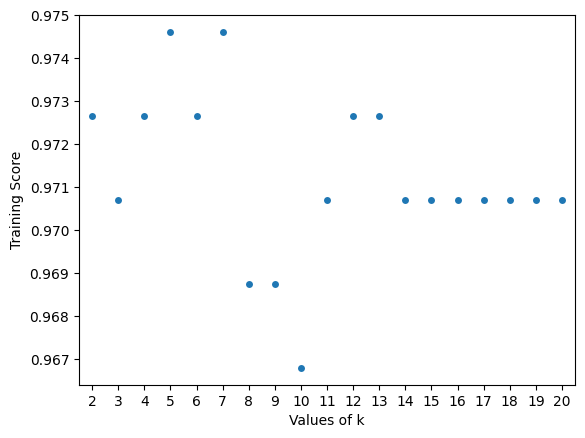

In [62]:
ax = sns.stripplot(x=K, y=training)  # Use x and y as keyword arguments
ax.set(xlabel='Values of k', ylabel='Training Score')
plt.show()

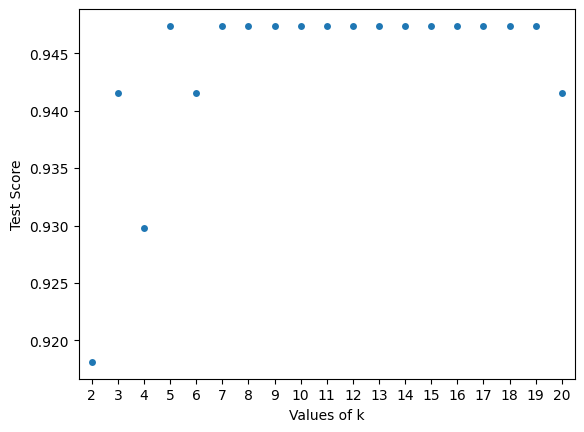

In [63]:
ax = sns.stripplot(x=K, y=test)  # Use x and y as keyword arguments
ax.set(xlabel='Values of k', ylabel='Test Score')
plt.show()

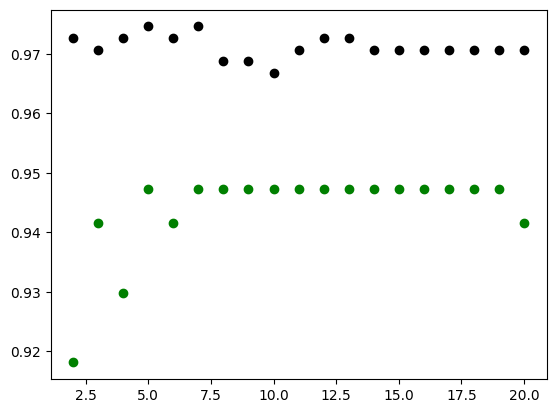

In [64]:
plt.scatter(K, training, color='k')
plt.scatter(K, test, color='g')
plt.show()

In [65]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

In [66]:
print("Reporte de clasificación de modelo sin balanceo:")
print(classification_report(y_test, y_pred))

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.93      0.99      0.96       103
           1       0.98      0.88      0.93        68

    accuracy                           0.95       171
   macro avg       0.96      0.94      0.94       171
weighted avg       0.95      0.95      0.95       171



**Interpretación de resultado: El modelo sin balanceo muestra buen desempeño general, pero puede presentar bajo recall en la clase minoritaria (malignos), lo cual implica riesgo de falsos negativos.**

## **c. Realice un balanceo de clases mediante la técnica SMOTE, vuelva a generar el modelo de clasificación, calcule sus métricas y compárelas con las del modelo sin balancear para ver si hubo o no mejoras.**

In [70]:
from imblearn.over_sampling import SMOTE

In [71]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [72]:
knn_smote = KNeighborsClassifier(n_neighbors=5)
knn_smote.fit(X_train_smote, y_train_smote)
y_pred_smote = knn_smote.predict(X_test)

In [73]:
print("Reporte de clasificación de modelo SMOTE:")
print(classification_report(y_test, y_pred_smote))

Reporte de clasificación de modelo SMOTE:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       103
           1       0.99      0.97      0.98        68

    accuracy                           0.98       171
   macro avg       0.98      0.98      0.98       171
weighted avg       0.98      0.98      0.98       171



**Al aplicar SMOTE permitio mejorar el desempeño del modelo especialmente de los casos maliganos aumentando su sensibilidad**